
🔥 Training 8x8
Epoch 0: D=1.341, G=0.597


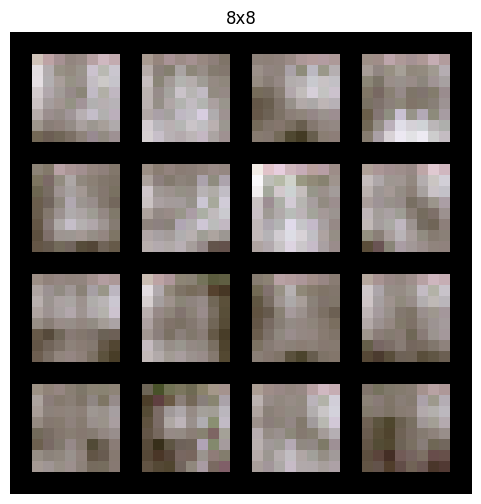

Epoch 1: D=1.135, G=0.700


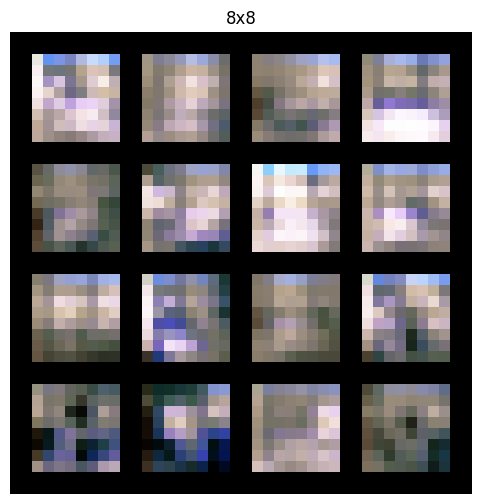


🔥 Training 16x16
Epoch 0: D=1.344, G=1.747


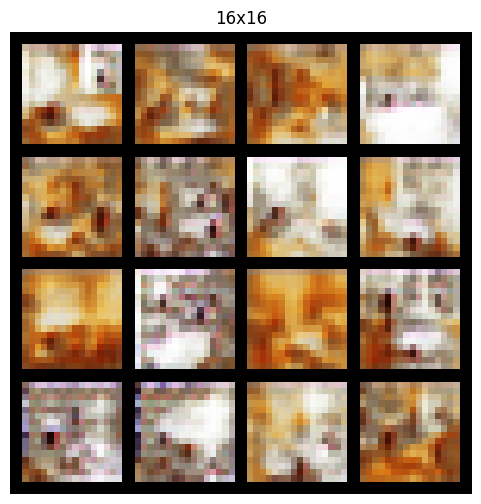

Epoch 1: D=1.030, G=1.108


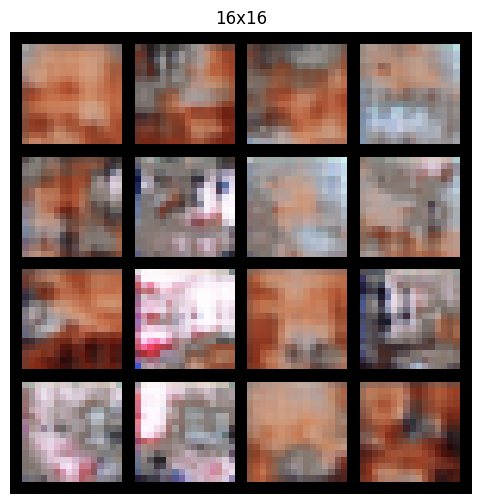


🔥 Training 32x32
Epoch 0: D=1.032, G=1.422


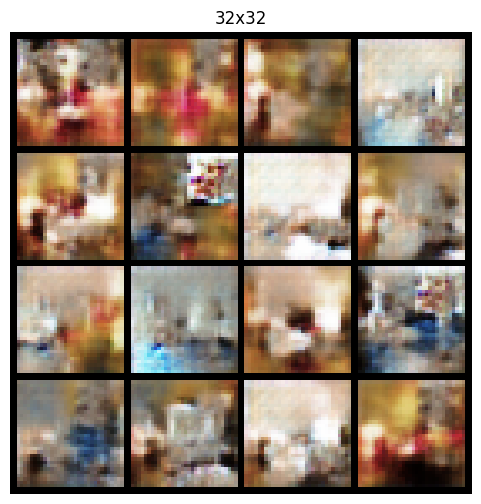

Epoch 1: D=0.862, G=1.727


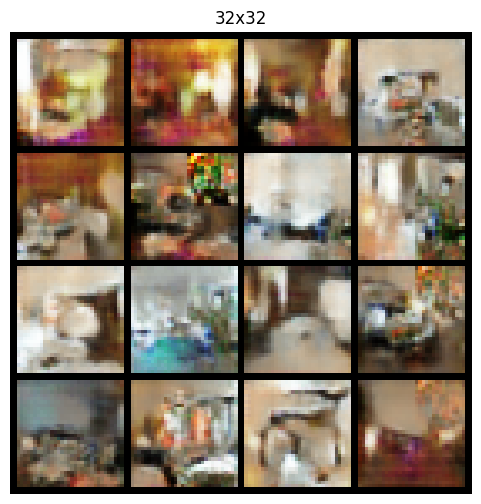

Epoch 2: D=0.742, G=1.538


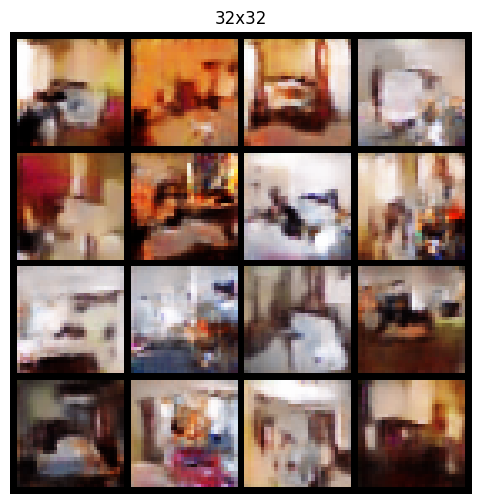


🔥 Training 64x64
Epoch 0: D=0.684, G=2.021


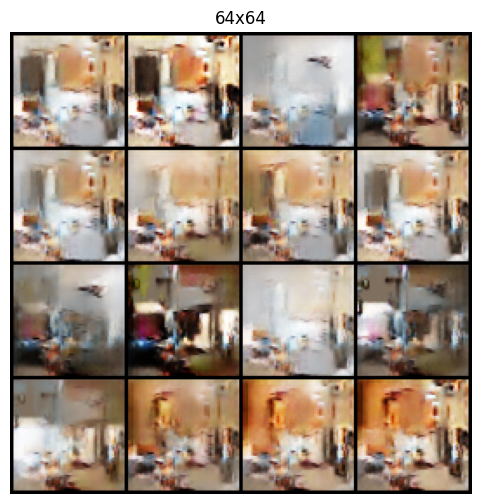

Epoch 1: D=0.750, G=2.099


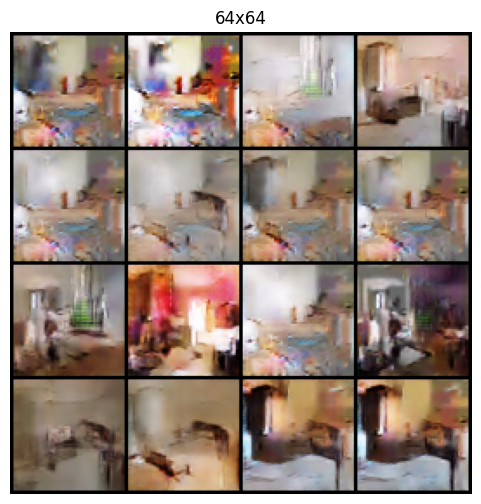

Epoch 2: D=1.263, G=1.960


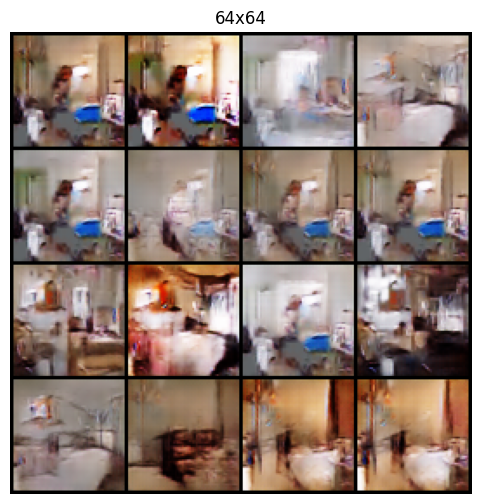

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Z_DIM = 128
CHANNELS = 128

EPOCHS = [2, 2, 3, 3]   # keep small for lab
BATCH_SIZES = [128, 64, 32, 16]

SIZES = [8, 16, 32, 64]

# =========================
# GENERATOR (stable)
# =========================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, CHANNELS, 4, 1, 0),   # 4x4
            nn.ReLU(),

            nn.ConvTranspose2d(CHANNELS, CHANNELS, 4, 2, 1), # 8x8
            nn.ReLU(),

            nn.ConvTranspose2d(CHANNELS, CHANNELS//2, 4, 2, 1), # 16x16
            nn.ReLU(),

            nn.ConvTranspose2d(CHANNELS//2, CHANNELS//4, 4, 2, 1), # 32x32
            nn.ReLU(),

            nn.ConvTranspose2d(CHANNELS//4, 3, 4, 2, 1), # 64x64
            nn.Tanh()
        )

    def forward(self, x, size):
        out = self.net(x)
        return nn.functional.interpolate(out, size=(size, size))  # progressive trick

# =========================
# DISCRIMINATOR
# =========================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, CHANNELS, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(CHANNELS, CHANNELS, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(CHANNELS, CHANNELS, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(CHANNELS, 1)
        )

    def forward(self, x):
        return self.net(x)

# =========================
# DATA LOADER (LSUN)
# =========================
def get_loader(size, batch):
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    dataset = ImageFolder(
        root="/kaggle/input/datasets/jhoward/lsun_bedroom/", 
        transform=transform
    )

    return DataLoader(dataset, batch_size=batch, shuffle=True, num_workers=2)

# =========================
# SHOW IMAGES
# =========================
def show(fake, title):
    fake = fake[:16] * 0.5 + 0.5
    grid = make_grid(fake, nrow=4)

    plt.figure(figsize=(6,6))
    plt.imshow(grid.cpu().permute(1,2,0))
    plt.title(title)
    plt.axis("off")
    plt.show()

# =========================
# TRAIN
# =========================
def train():
    gen = Generator().to(DEVICE)
    disc = Discriminator().to(DEVICE)

    opt_g = optim.Adam(gen.parameters(), lr=1e-4)
    opt_d = optim.Adam(disc.parameters(), lr=1e-4)

    loss_fn = nn.BCEWithLogitsLoss()

    fixed_noise = torch.randn(16, Z_DIM, 1, 1).to(DEVICE)

    for i, size in enumerate(SIZES):
        print(f"\n🔥 Training {size}x{size}")

        loader = get_loader(size, BATCH_SIZES[i])

        for epoch in range(EPOCHS[i]):
            for real, _ in loader:
                real = real.to(DEVICE)
                batch = real.size(0)

                # ---- Discriminator ----
                noise = torch.randn(batch, Z_DIM, 1, 1).to(DEVICE)
                fake = gen(noise, size)

                real_loss = loss_fn(disc(real), torch.ones(batch,1).to(DEVICE))
                fake_loss = loss_fn(disc(fake.detach()), torch.zeros(batch,1).to(DEVICE))

                loss_d = real_loss + fake_loss

                opt_d.zero_grad()
                loss_d.backward()
                opt_d.step()

                # ---- Generator ----
                noise = torch.randn(batch, Z_DIM, 1, 1).to(DEVICE)
                fake = gen(noise, size)

                loss_g = loss_fn(disc(fake), torch.ones(batch,1).to(DEVICE))

                opt_g.zero_grad()
                loss_g.backward()
                opt_g.step()

            print(f"Epoch {epoch}: D={loss_d.item():.3f}, G={loss_g.item():.3f}")

            with torch.no_grad():
                fake = gen(fixed_noise, size)
                show(fake, f"{size}x{size}")

train()